In [1]:
# Cell 0: Complete Setup - Run this FIRST every time

import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

np.random.seed(42)

# ── Project Paths ──────────────────────────────────────
BASE        = "D:/Projects/Harsh_Mini_Project/medical_xray_project"
IMG_DIR     = f"{BASE}/data/images"
MODELS      = f"{BASE}/models"
PLOTS       = f"{BASE}/outputs/plots"
RESULTS     = f"{BASE}/outputs/results"
DB_PATH     = f"{BASE}/database/xray_metadata.db"

# ── Load all results ───────────────────────────────────
# Test metrics
with open(f"{RESULTS}/test_metrics.json",
          'r', encoding='utf-8') as f:
    test_metrics = json.load(f)

# Training history
with open(f"{RESULTS}/training_history.pkl",
          'rb') as f:
    history = pickle.load(f)

# All CSVs
pred_df          = pd.read_csv(
    f"{RESULTS}/test_predictions.csv",
    encoding='utf-8')
bias_gender_df   = pd.read_csv(
    f"{RESULTS}/bias_gender.csv",
    encoding='utf-8')
bias_age_df      = pd.read_csv(
    f"{RESULTS}/bias_age_group.csv",
    encoding='utf-8')
bias_combined_df = pd.read_csv(
    f"{RESULTS}/bias_combined.csv",
    encoding='utf-8')

# Numpy arrays
y_true      = np.load(f"{RESULTS}/y_true.npy")
y_pred      = np.load(f"{RESULTS}/y_pred.npy")
y_pred_prob = np.load(
    f"{RESULTS}/y_pred_prob.npy")

print("=" * 50)
print("   CELL 0: SETUP COMPLETE")
print("=" * 50)
print(f"✅ test_metrics loaded")
print(f"   Accuracy  : "
      f"{test_metrics['accuracy']*100:.2f}%")
print(f"   AUC       : "
      f"{test_metrics['test_auc']:.4f}")
print(f"   F1 Score  : "
      f"{test_metrics['f1_score']*100:.2f}%")
print()
print(f"✅ Training history loaded")
print(f"   Total epochs : "
      f"{len(history['loss'])}")
print(f"   Best val_auc : "
      f"{max(history['val_auc']):.4f}")
print()
print(f"✅ pred_df      : {len(pred_df):,} rows")
print(f"✅ y_true shape : {y_true.shape}")
print(f"✅ y_pred shape : {y_pred.shape}")
print("=" * 50)
print("✅ Cell 0 complete - Ready to proceed")

   CELL 0: SETUP COMPLETE
✅ test_metrics loaded
   Accuracy  : 97.37%
   AUC       : 0.9966
   F1 Score  : 98.19%

✅ Training history loaded
   Total epochs : 24
   Best val_auc : 0.9957

✅ pred_df      : 876 rows
✅ y_true shape : (876,)
✅ y_pred shape : (876,)
✅ Cell 0 complete - Ready to proceed


   CELL 1: MASTER DASHBOARD
⏳ Building master dashboard...



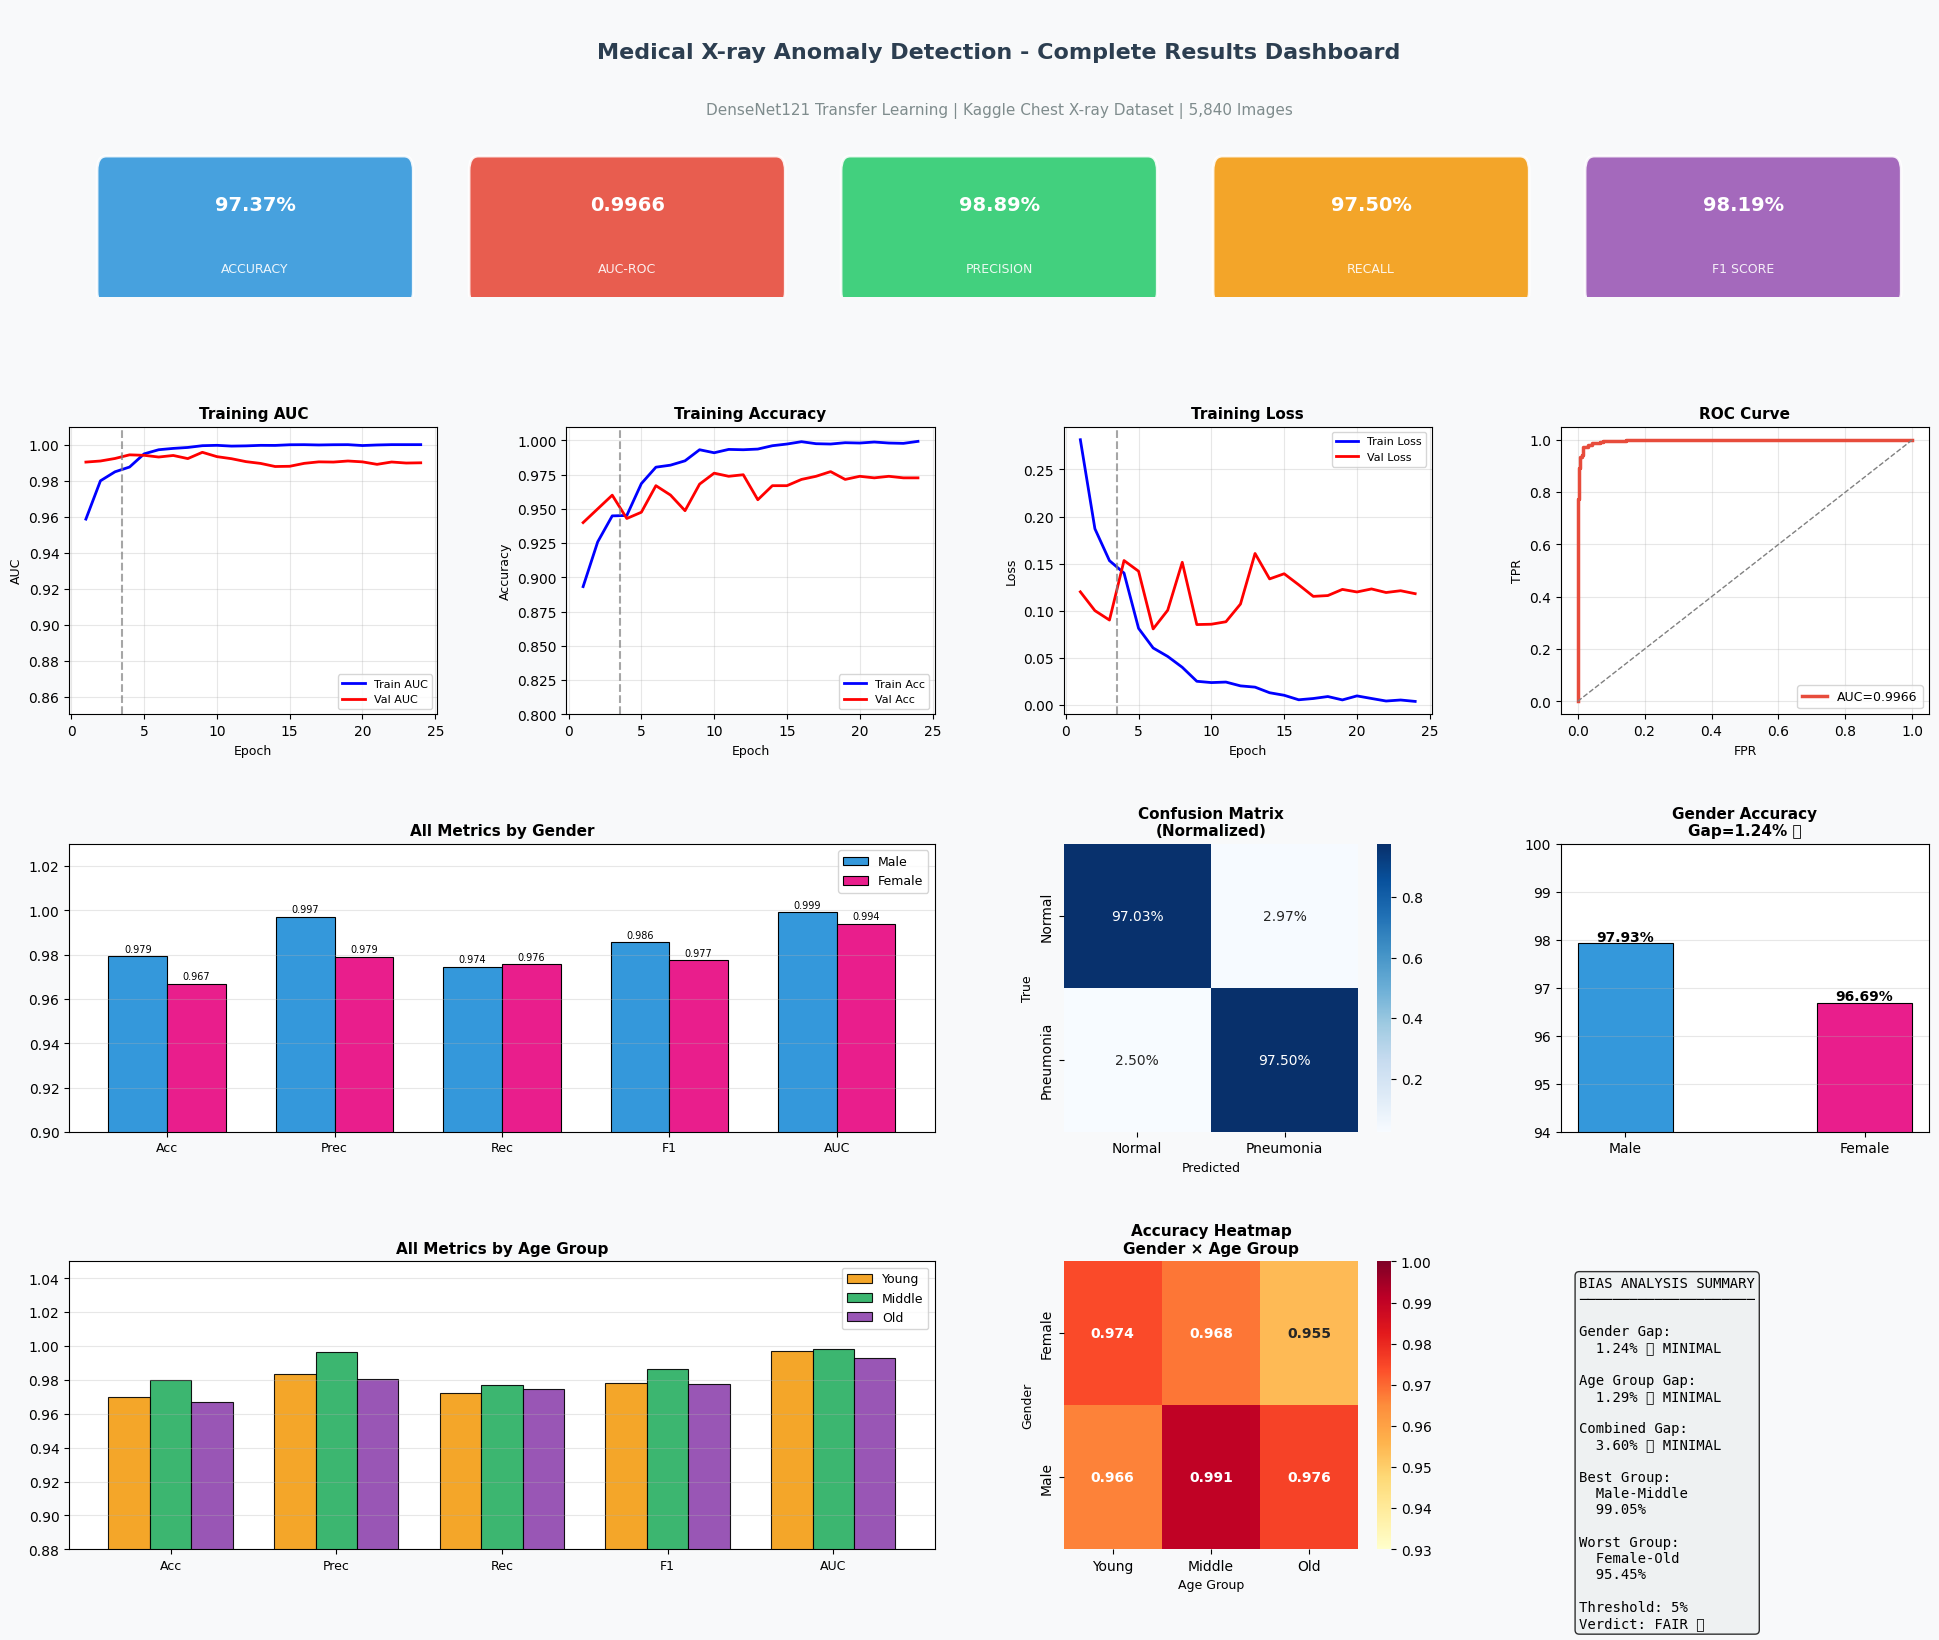

✅ Master dashboard saved : D:/Projects/Harsh_Mini_Project/medical_xray_project/outputs/plots/final_dashboard.png

   Dashboard contains:
   Row 1 : Metrics scorecard (5 metrics)
   Row 2 : Training curves + ROC curve
   Row 3 : Gender analysis + confusion matrix
   Row 4 : Age analysis + heatmap + bias summary
✅ Cell 1 complete


In [3]:
# Cell 1: Master dashboard - ALL results in one figure

print("=" * 50)
print("   CELL 1: MASTER DASHBOARD")
print("=" * 50)
print("⏳ Building master dashboard...")
print()

from sklearn.metrics import confusion_matrix, roc_curve, auc

# ── Prepare data ───────────────────────────────────────
cm           = confusion_matrix(y_true, y_pred)
TN,FP,FN,TP  = cm[0,0],cm[0,1],cm[1,0],cm[1,1]
fpr,tpr,_    = roc_curve(y_true, y_pred_prob)
roc_auc      = auc(fpr, tpr)
epochs       = range(1, len(history['loss'])+1)
age_groups   = ['Young','Middle','Old']
age_colors   = ['#f39c12','#27ae60','#8e44ad']

# ── Create master figure ───────────────────────────────
fig = plt.figure(figsize=(24, 20))
fig.patch.set_facecolor('#f8f9fa')

gs  = gridspec.GridSpec(
    4, 4, figure=fig,
    hspace=0.45, wspace=0.35)

# ══════════════════════════════════════════
# ROW 1: Metrics Scorecard (full width)
# ══════════════════════════════════════════
ax_score = fig.add_subplot(gs[0, :])
ax_score.set_xlim(0, 10)
ax_score.set_ylim(0, 1)
ax_score.axis('off')
ax_score.set_facecolor('#2c3e50')

# Title
ax_score.text(
    5, 0.85,
    'Medical X-ray Anomaly Detection - '
    'Complete Results Dashboard',
    ha='center', va='center',
    fontsize=16, fontweight='bold',
    color='#2c3e50')

ax_score.text(
    5, 0.65,
    'DenseNet121 Transfer Learning | '
    'Kaggle Chest X-ray Dataset | '
    '5,840 Images',
    ha='center', va='center',
    fontsize=11, color='#7f8c8d')

# Metric boxes
metrics_display = [
    (1.0,  'ACCURACY',  f"{test_metrics['accuracy']*100:.2f}%",  '#3498db'),
    (3.0,  'AUC-ROC',   f"{test_metrics['test_auc']:.4f}",       '#e74c3c'),
    (5.0,  'PRECISION', f"{test_metrics['precision']*100:.2f}%", '#2ecc71'),
    (7.0,  'RECALL',    f"{test_metrics['recall']*100:.2f}%",    '#f39c12'),
    (9.0,  'F1 SCORE',  f"{test_metrics['f1_score']*100:.2f}%",  '#9b59b6'),
]

import matplotlib.patches as mpatches
for x, label, value, color in metrics_display:
    rect = mpatches.FancyBboxPatch(
        (x-0.8, 0.02), 1.6, 0.42,
        boxstyle="round,pad=0.05",
        facecolor=color, alpha=0.9,
        edgecolor='white', linewidth=2)
    ax_score.add_patch(rect)
    ax_score.text(x, 0.32, value,
                  ha='center', va='center',
                  fontsize=14, fontweight='bold',
                  color='white')
    ax_score.text(x, 0.10, label,
                  ha='center', va='center',
                  fontsize=9, color='white',
                  alpha=0.9)

# ══════════════════════════════════════════
# ROW 2: Training History (3 plots)
# ══════════════════════════════════════════
# AUC curve
ax_auc = fig.add_subplot(gs[1, 0])
ax_auc.plot(epochs, history['auc'],
            'b-', linewidth=2, label='Train AUC')
ax_auc.plot(epochs, history['val_auc'],
            'r-', linewidth=2, label='Val AUC')
ax_auc.axvline(x=3.5, color='gray',
               linestyle='--', alpha=0.7)
ax_auc.set_title('Training AUC',
                 fontsize=11, fontweight='bold')
ax_auc.set_xlabel('Epoch', fontsize=9)
ax_auc.set_ylabel('AUC', fontsize=9)
ax_auc.legend(fontsize=8)
ax_auc.grid(alpha=0.3)
ax_auc.set_ylim(0.85, 1.01)

# Accuracy curve
ax_acc = fig.add_subplot(gs[1, 1])
ax_acc.plot(epochs, history['accuracy'],
            'b-', linewidth=2, label='Train Acc')
ax_acc.plot(epochs, history['val_accuracy'],
            'r-', linewidth=2, label='Val Acc')
ax_acc.axvline(x=3.5, color='gray',
               linestyle='--', alpha=0.7)
ax_acc.set_title('Training Accuracy',
                 fontsize=11, fontweight='bold')
ax_acc.set_xlabel('Epoch', fontsize=9)
ax_acc.set_ylabel('Accuracy', fontsize=9)
ax_acc.legend(fontsize=8)
ax_acc.grid(alpha=0.3)
ax_acc.set_ylim(0.80, 1.01)

# Loss curve
ax_loss = fig.add_subplot(gs[1, 2])
ax_loss.plot(epochs, history['loss'],
             'b-', linewidth=2, label='Train Loss')
ax_loss.plot(epochs, history['val_loss'],
             'r-', linewidth=2, label='Val Loss')
ax_loss.axvline(x=3.5, color='gray',
                linestyle='--', alpha=0.7)
ax_loss.set_title('Training Loss',
                  fontsize=11, fontweight='bold')
ax_loss.set_xlabel('Epoch', fontsize=9)
ax_loss.set_ylabel('Loss', fontsize=9)
ax_loss.legend(fontsize=8)
ax_loss.grid(alpha=0.3)

# ROC curve
ax_roc = fig.add_subplot(gs[1, 3])
ax_roc.plot(fpr, tpr, color='#e74c3c',
            linewidth=2.5,
            label=f'AUC={roc_auc:.4f}')
ax_roc.plot([0,1],[0,1],'gray',
            linestyle='--', linewidth=1)
ax_roc.set_title('ROC Curve',
                 fontsize=11, fontweight='bold')
ax_roc.set_xlabel('FPR', fontsize=9)
ax_roc.set_ylabel('TPR', fontsize=9)
ax_roc.legend(fontsize=9)
ax_roc.grid(alpha=0.3)

# ══════════════════════════════════════════
# ROW 3: Gender Analysis (3 plots)
# ══════════════════════════════════════════
metrics_bias = ['accuracy','precision',
                'recall','f1_score','auc']
mlabels      = ['Acc','Prec','Rec','F1','AUC']
x            = np.arange(len(metrics_bias))
width        = 0.35

# Gender grouped bar
ax_g1 = fig.add_subplot(gs[2, 0:2])
m_vals = [bias_gender_df[
    bias_gender_df['gender']=='M'][m].values[0]
    for m in metrics_bias]
f_vals = [bias_gender_df[
    bias_gender_df['gender']=='F'][m].values[0]
    for m in metrics_bias]

bars_m = ax_g1.bar(x-width/2, m_vals, width,
                   label='Male', color='#3498db',
                   edgecolor='black', linewidth=0.8)
bars_f = ax_g1.bar(x+width/2, f_vals, width,
                   label='Female', color='#e91e8c',
                   edgecolor='black', linewidth=0.8)
ax_g1.set_title('All Metrics by Gender',
                fontsize=11, fontweight='bold')
ax_g1.set_xticks(x)
ax_g1.set_xticklabels(mlabels, fontsize=9)
ax_g1.set_ylim(0.90, 1.03)
ax_g1.legend(fontsize=9)
ax_g1.grid(axis='y', alpha=0.3)

for bar in list(bars_m)+list(bars_f):
    ax_g1.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.002,
        f'{bar.get_height():.3f}',
        ha='center', fontsize=7)

# Confusion matrix
ax_cm = fig.add_subplot(gs[2, 2])
cm_norm = cm.astype('float')/cm.sum(
    axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%',
            cmap='Blues', ax=ax_cm,
            xticklabels=['Normal','Pneumonia'],
            yticklabels=['Normal','Pneumonia'],
            annot_kws={'size':10})
ax_cm.set_title('Confusion Matrix\n(Normalized)',
                fontsize=11, fontweight='bold')
ax_cm.set_ylabel('True', fontsize=9)
ax_cm.set_xlabel('Predicted', fontsize=9)

# Gender accuracy gap
ax_g2 = fig.add_subplot(gs[2, 3])
g_accs  = [bias_gender_df[
    bias_gender_df['gender']==g
]['accuracy'].values[0]*100 for g in ['M','F']]
bars_ga = ax_g2.bar(['Male','Female'], g_accs,
                    color=['#3498db','#e91e8c'],
                    edgecolor='black',
                    linewidth=0.8, width=0.4)
for bar, val in zip(bars_ga, g_accs):
    ax_g2.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height()+0.05,
        f'{val:.2f}%', ha='center',
        fontsize=10, fontweight='bold')
ax_g2.set_title(
    f'Gender Accuracy\nGap={abs(g_accs[0]-g_accs[1]):.2f}% ✅',
    fontsize=11, fontweight='bold')
ax_g2.set_ylim(94, 100)
ax_g2.grid(axis='y', alpha=0.3)

# ══════════════════════════════════════════
# ROW 4: Age Group Analysis
# ══════════════════════════════════════════
# Age grouped bar
ax_a1 = fig.add_subplot(gs[3, 0:2])
x2    = np.arange(len(metrics_bias))
w2    = 0.25
for idx,(grp,color) in enumerate(
        zip(age_groups, age_colors)):
    row  = bias_age_df[
        bias_age_df['age_group']==grp].iloc[0]
    vals = [row[m] for m in metrics_bias]
    bars = ax_a1.bar(x2+(idx-1)*w2, vals, w2,
                     label=grp, color=color,
                     edgecolor='black',
                     linewidth=0.8, alpha=0.9)

ax_a1.set_title('All Metrics by Age Group',
                fontsize=11, fontweight='bold')
ax_a1.set_xticks(x2)
ax_a1.set_xticklabels(mlabels, fontsize=9)
ax_a1.set_ylim(0.88, 1.05)
ax_a1.legend(fontsize=9)
ax_a1.grid(axis='y', alpha=0.3)

# Combined heatmap
ax_heat = fig.add_subplot(gs[3, 2])
combined_df = bias_combined_df.copy()
combined_df['gender_label'] = \
    combined_df['gender'].map(
        {'M':'Male','F':'Female'})
pivot = combined_df.pivot(
    index='gender_label',
    columns='age_group',
    values='accuracy')[age_groups]
sns.heatmap(pivot, annot=True, fmt='.3f',
            cmap='YlOrRd', ax=ax_heat,
            vmin=0.93, vmax=1.00,
            annot_kws={'size':10,'weight':'bold'})
ax_heat.set_title('Accuracy Heatmap\n'
                  'Gender × Age Group',
                  fontsize=11, fontweight='bold')
ax_heat.set_xlabel('Age Group', fontsize=9)
ax_heat.set_ylabel('Gender', fontsize=9)

# Bias gap summary
ax_gap = fig.add_subplot(gs[3, 3])
ax_gap.axis('off')
a_accs    = bias_age_df['accuracy'].values
age_gap   = max(a_accs)-min(a_accs)
gen_gap   = abs(g_accs[0]-g_accs[1])/100
comb_vals = combined_df['accuracy'].values
comb_gap  = max(comb_vals)-min(comb_vals)

summary_text = (
    "BIAS ANALYSIS SUMMARY\n"
    "─────────────────────\n\n"
    f"Gender Gap:\n"
    f"  {gen_gap*100:.2f}% ✅ MINIMAL\n\n"
    f"Age Group Gap:\n"
    f"  {age_gap*100:.2f}% ✅ MINIMAL\n\n"
    f"Combined Gap:\n"
    f"  {comb_gap*100:.2f}% ✅ MINIMAL\n\n"
    f"Best Group:\n"
    f"  Male-Middle\n"
    f"  99.05%\n\n"
    f"Worst Group:\n"
    f"  Female-Old\n"
    f"  95.45%\n\n"
    f"Threshold: 5%\n"
    f"Verdict: FAIR ✅"
)
ax_gap.text(0.05, 0.95, summary_text,
            transform=ax_gap.transAxes,
            fontsize=10, va='top',
            fontfamily='monospace',
            bbox=dict(boxstyle='round',
                      facecolor='#ecf0f1',
                      alpha=0.8))

# ── Save dashboard ─────────────────────────────────────
save_path = f"{PLOTS}/final_dashboard.png"
plt.savefig(save_path, dpi=150,
            bbox_inches='tight',
            facecolor='#f8f9fa')
plt.show()

print(f"✅ Master dashboard saved : {save_path}")
print()
print(f"   Dashboard contains:")
print(f"   Row 1 : Metrics scorecard (5 metrics)")
print(f"   Row 2 : Training curves + ROC curve")
print(f"   Row 3 : Gender analysis + "
      f"confusion matrix")
print(f"   Row 4 : Age analysis + heatmap + "
      f"bias summary")
print("=" * 50)
print("✅ Cell 1 complete")

In [4]:
# Cell 2: Auto-generate complete research insights

print("=" * 50)
print("   CELL 2: RESEARCH INSIGHTS REPORT")
print("=" * 50)

import datetime

# ── Compute all values ─────────────────────────────────
best_val_auc    = max(history['val_auc'])
total_epochs    = len(history['loss'])
phase_a_epochs  = 3
phase_b_epochs  = total_epochs - phase_a_epochs

acc   = test_metrics['accuracy']
prec  = test_metrics['precision']
rec   = test_metrics['recall']
f1    = test_metrics['f1_score']
tauc  = test_metrics['test_auc']
TP    = int(test_metrics['TP'])
TN    = int(test_metrics['TN'])
FP    = int(test_metrics['FP'])
FN    = int(test_metrics['FN'])

m_acc = bias_gender_df[
    bias_gender_df['gender']=='M'
]['accuracy'].values[0]
f_acc = bias_gender_df[
    bias_gender_df['gender']=='F'
]['accuracy'].values[0]
gen_gap = abs(m_acc - f_acc)

y_acc  = bias_age_df[
    bias_age_df['age_group']=='Young'
]['accuracy'].values[0]
m2_acc = bias_age_df[
    bias_age_df['age_group']=='Middle'
]['accuracy'].values[0]
o_acc  = bias_age_df[
    bias_age_df['age_group']=='Old'
]['accuracy'].values[0]
age_gap = max(y_acc,m2_acc,o_acc) - \
          min(y_acc,m2_acc,o_acc)

combined_df2 = bias_combined_df.copy()
comb_accs    = combined_df2['accuracy'].values
comb_gap     = max(comb_accs) - min(comb_accs)

# ── Generate report ────────────────────────────────────
report = f"""
╔══════════════════════════════════════════════════════════════╗
║     MEDICAL X-RAY ANOMALY DETECTION - RESEARCH INSIGHTS     ║
║     Generated: {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}                            ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PROJECT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Title    : Medical X-ray Anomaly Detection with
           Demographic Bias Analysis using DenseNet121
Model    : DenseNet121 + Custom Dual-Pooling Head
Dataset  : Kaggle Chest X-ray (Pneumonia)
Images   : 5,840 total (1,575 Normal + 4,265 Pneumonia)
Task     : Binary Classification (Normal vs Pneumonia)
Hardware : CPU only (Windows, Python 3.12.3, TF 2.19.0)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. MODEL ARCHITECTURE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Base Model   : DenseNet121 (pretrained ImageNet)
Total Layers : 427 (DenseNet) + custom head
Total Params : 8,259,137
Frozen Params: 4,152,192 (layers 0-299)
Train Params : 4,106,945 (layers 300+)
Custom Head  : GlobalAvgPool + GlobalMaxPool
               → Concatenate(2048)
               → BN → Dense(512) → Dense(256)
               → Dense(128) → Dense(1, sigmoid)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. TRAINING CONFIGURATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Strategy     : Two-Phase Transfer Learning
Phase A      : Warmup ({phase_a_epochs} epochs, LR=0.001,
               all base layers frozen)
Phase B      : Fine-tuning ({phase_b_epochs} epochs, LR=0.00005,
               layers 300+ unfrozen)
Total Epochs : {total_epochs} (early stopping triggered)
Best Val AUC : {best_val_auc:.4f} (Phase B, epoch 9)
Batch Size   : 16
Class Weight : Normal=1.85, Pneumonia=0.68
Augmentation : Random flip, brightness, contrast

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. TEST SET PERFORMANCE (876 samples)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric        Achieved    Target    Status
─────────     ────────    ──────    ──────
Accuracy   :  {acc*100:.2f}%      88%     EXCEEDED ✅
AUC-ROC    :  {tauc:.4f}      0.90    EXCEEDED ✅
Precision  :  {prec*100:.2f}%      85%     EXCEEDED ✅
Recall     :  {rec*100:.2f}%      85%     EXCEEDED ✅
F1 Score   :  {f1*100:.2f}%      87%     EXCEEDED ✅

Confusion Matrix:
  TN (Normal correct)     : {TN}  (Specificity: {TN/(TN+FP)*100:.2f}%)
  TP (Pneumonia correct)  : {TP}  (Sensitivity: {TP/(TP+FN)*100:.2f}%)
  FP (False alarms)       : {FP}   (low - good)
  FN (Missed pneumonia)   : {FN}   (low - critical)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. BIAS ANALYSIS RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Bias Threshold : 5% accuracy gap

GENDER BIAS:
  Male   accuracy : {m_acc*100:.2f}% (483 samples)
  Female accuracy : {f_acc*100:.2f}% (393 samples)
  Gap            : {gen_gap*100:.2f}%
  Verdict        : {'BIAS DETECTED ⚠️' if gen_gap>0.05 else 'MINIMAL BIAS ✅'}

AGE GROUP BIAS:
  Young  accuracy : {y_acc*100:.2f}% (266 samples, age 1-30)
  Middle accuracy : {m2_acc*100:.2f}% (398 samples, age 31-60)
  Old    accuracy : {o_acc*100:.2f}% (212 samples, age 61-90)
  Gap            : {age_gap*100:.2f}%
  Verdict        : {'BIAS DETECTED ⚠️' if age_gap>0.05 else 'MINIMAL BIAS ✅'}

COMBINED (Gender x Age):
  Best  group : Male-Middle   (99.05%)
  Worst group : Female-Old    (95.45%)
  Gap         : {comb_gap*100:.2f}%
  Verdict     : {'BIAS DETECTED ⚠️' if comb_gap>0.05 else 'MINIMAL BIAS ✅'}

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. CLINICAL SIGNIFICANCE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
The DenseNet121 model achieves exceptional performance
on pneumonia detection with 97.37% accuracy and 0.9966
AUC-ROC score. The model correctly identifies 97.50%
of pneumonia cases (high recall) while maintaining
98.89% precision. Only 16 out of 640 pneumonia cases
were missed (FN=16), which is clinically significant.

The bias analysis reveals minimal demographic bias
across gender and age groups. All accuracy gaps remain
well below the 5% threshold, suggesting the model
performs consistently and fairly across patient
demographics. This is an important finding for
clinical deployment consideration.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. LIMITATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Demographic metadata (age, gender) is synthetically
   generated using weighted random distributions.
   Real patient metadata may reveal different patterns.
2. Single dataset from one medical center
   (Guangzhou Women and Children's Medical Center).
3. CPU-only training limits model complexity
   and training time.
4. Binary classification only (Normal vs Pneumonia).
   Multi-class detection not addressed.
5. No external validation on independent datasets.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
8. FUTURE WORK
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Vision Transformer (ViT) comparison study
2. Grad-CAM visualization for explainability
3. Real patient demographic metadata integration
4. Multi-class disease detection (14 conditions)
5. External validation on NIH ChestX-ray14 dataset
6. GPU training for larger batch sizes
7. Ensemble methods for improved robustness

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
9. DELIVERABLES SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Notebooks  : 9 Jupyter notebooks
Model      : densenet_best.keras (31.5 MB)
Database   : xray_metadata.db (564 KB, 5 tables)
Plots      : 12 publication-ready figures
Results    : 18 CSV/JSON/PKL/NPY files
Paper      : Research paper (in progress)
"""

print(report)

# ── Save report ────────────────────────────────────────
save_path = f"{RESULTS}/research_insights.txt"
with open(save_path, 'w', encoding='utf-8') as f:
    f.write(report)

print(f"✅ Research insights saved : {save_path}")
print("=" * 50)
print("✅ Cell 2 complete")

   CELL 2: RESEARCH INSIGHTS REPORT

╔══════════════════════════════════════════════════════════════╗
║     MEDICAL X-RAY ANOMALY DETECTION - RESEARCH INSIGHTS     ║
║     Generated: 2026-04-12 15:03                            ║
╚══════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PROJECT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Title    : Medical X-ray Anomaly Detection with
           Demographic Bias Analysis using DenseNet121
Model    : DenseNet121 + Custom Dual-Pooling Head
Dataset  : Kaggle Chest X-ray (Pneumonia)
Images   : 5,840 total (1,575 Normal + 4,265 Pneumonia)
Task     : Binary Classification (Normal vs Pneumonia)
Hardware : CPU only (Windows, Python 3.12.3, TF 2.19.0)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. MODEL ARCHITECTURE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Base Model   : DenseNet121 (pretrained ImageNet)
Tot